# 04 — Spp1-Cd44: who makes it, and do SPP1-TAM macrophages localize into that field?

Answers: *"Are the SPP1-TAM macrophages actually sitting in the high Spp1-Cd44 signal? How do
these Spp1-Cd44 interactions vary per condition?"*

**Graded rewrite.** The old binary "Spp1+ mac" identity (raw Spp1 counts >= 2) is spillover-
contaminated (01/01b/01c), so it is no longer used to *define* macrophage state. Two places use
the graded `SPP1_TAM_sig` instead: section 5 (are high-signature macs the cells in the
Spp1-Cd44 hotspots?) and section 6 (per-condition, do high-signature macs carry more local
Spp1-Cd44?). Section 3 still apportions **raw** Spp1 transcript by cell type — that is
legitimate (it is counting molecules, not calling a cell state) and it is what decides whether
this is a macrophage story at all.

### Section 3 comes first, and it can reframe the story
`Spp1` is not macrophage-specific — tumor, fibroblast and osteoblast-lineage cells express it
heavily, and in many tumors the *dominant* Spp1 source is the tumor. If tumor cells make most
of the Spp1, a "Spp1-Cd44 hotspot" is a **tumor-CD44 axis** that SPP1-TAM macs merely sit
inside — the claim becomes "SPP1-TAM macs *localize to* a tumor-driven Spp1-CD44 niche," which
is exactly the PDF's model (macs as responders/readout), not "SPP1-TAM macs signal to CD44."

### A note on the LIANA call
`resource_name='mouseconsensus'` is keyed on **mouse** symbols (`Spp1`, `Cd44`) and matches
`var_names` directly. The old "uses HUMAN gene symbols" comment was a leftover from the human
`consensus` resource and is wrong. Section 4 asserts the overlap rather than trusting the note.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import scanpy as sc
import spatialdata as spd
import liana as li

try:
    from spatialdata.transformations import get_transformation
except Exception:
    get_transformation = None

from scipy.stats import mannwhitneyu, spearmanr
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 220)

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## 1. Config

In [2]:
PROJ_DIR  = Path("/coh_labs/yunroseli/Jona/CAR-T")
ZARR_FILE = PROJ_DIR / "data/zarr/fullDataset/processing_Zarr/1_C2l_annotated_CC"
OUT_DIR   = PROJ_DIR / "results/spp1_analysis"
FIG_DIR   = OUT_DIR / "figures"
SIG_CSV   = OUT_DIR / "sc_spp1_tam_signature.csv"      # written by 01c §5
OUT_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)

TISSUE_COL, CELL_TYPE_COL = "tissue", "c2l_consolidated"
MAC_LABELS = ["M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"]
SPP1_THRESHOLD = 2       # only for the raw-transcript source table in section 3

MICRONS_PER_PIXEL, APPLY_HIRES_SCALE = 0.34, True
# liana's `bandwidth` is expressed in the units of obsm[spatial_key], and ours is PIXELS.
# §4 therefore writes micron coords into obsm["spatial_um"] and points liana at that, so the
# bandwidth below is real microns and directly comparable to NEIGHBOR_RADIUS_UM=50 in 02/03/06.
LR_BANDWIDTH_UM   = 50   # signalling length (microns)
LR_MAX_NEIGHBOURS = 100  # max edges per cell (liana default; 'n_neighs' is squidpy's name, not liana's)
LR_CUTOFF         = 0.1  # connectivity weights below this are zeroed (liana default)
LR_N_PERMS   = 100       # matches your original call
LR_NZ_PROP   = 0.05
MIN_CELLS    = 100
TOP_Q        = 0.90      # "high Spp1-Cd44" = top decile of local score within a tissue
SIG_HIGH_Q   = 0.75      # high-signature mac = top quartile of SPP1_TAM_sig across pooled macs

# LIANA per-tissue is the expensive step. Smoke-test on 2 tissues first.
TISSUE_SUBSET = None     # e.g. ["RTCyPSCA_1_2", "CyPSCA_1_1"]

print("config ready ->", OUT_DIR)

config ready -> /coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis


## 2. Load + labels (graded signature + raw-transcript columns for section 3)

In [3]:
sdata = spd.read_zarr(ZARR_FILE)
adata = sdata.tables["segmentation_counts"]

def raw_counts(gene):
    i = int(adata.var_names.get_loc(gene))
    c = adata.layers["counts"][:, i]
    return np.asarray(c.todense()).ravel() if sp.issparse(c) else np.asarray(c).ravel()

spp1_counts = raw_counts("Spp1")
adata.obs["Spp1_counts"] = spp1_counts

# graded SPP1-TAM signature (same as 02/03) -> the identity we actually trust
sig_genes = pd.read_csv(SIG_CSV)["gene"].tolist()
present = [g for g in sig_genes if g in adata.var_names]
print(f"signature: {len(present)}/{len(sig_genes)} genes present in spatial")
if len(present) < len(sig_genes):
    print("  missing:", [g for g in sig_genes if g not in adata.var_names])
assert len(present) >= 8, "too few signature genes present"
sc.tl.score_genes(adata, gene_list=present, score_name="SPP1_TAM_sig", use_raw=False, random_state=0)

ct = adata.obs[CELL_TYPE_COL].astype(str)
adata.obs["is_mac"]   = ct.isin(MAC_LABELS).values
# high-signature mac = top quartile of the signature among all macs (global cut, matches 02)
mac_sig = adata.obs.loc[adata.obs["is_mac"], "SPP1_TAM_sig"]
SIG_CUT = float(mac_sig.quantile(SIG_HIGH_Q))
adata.obs["highsig_mac"] = adata.obs["is_mac"].values & (adata.obs["SPP1_TAM_sig"].values >= SIG_CUT)
# kept only for the section-3 raw-transcript source table, not used as an identity downstream
adata.obs["spp1_mac"] = adata.obs["is_mac"].values & (spp1_counts >= SPP1_THRESHOLD)

def parse_tissue(t):
    m = re.match(r"^(.*)_(\d+)_(\d+)$", str(t))
    return (m.group(1), int(m.group(2)), int(m.group(3))) if m else (None, None, None)

def rt_group_of(cond, loc):
    return "no_RT" if not str(cond).startswith("RT") else ("RT_direct" if loc == 1 else "RT_abscopal")

print(f"macs {int(adata.obs['is_mac'].sum()):,} | high-signature macs "
      f"{int(adata.obs['highsig_mac'].sum()):,} (SPP1_TAM_sig >= {SIG_CUT:.3f})")

root_attr: omero
root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: 0
 - shape ('c', 'y', 'x') = (3, 2798, 2748)
 - chunks =  ['3', '2798', '2748']
 - dtype = uint8
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero
root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: 0
 - shape ('c', 'y', 'x') = (3, 2398, 2865)
 - chunks =  ['3', '2398', '2865']
 - dtype = uint8
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero
root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0, 1.0]}]}]
resolution: 0
 - shape ('c', 'y', 'x') = (3, 2506, 2679)
 - chunks =  ['3', '2506', '2679']
 - dtype = uint8
root_attr: omero
root_attr: version
root_attr: multiscales
root_attr: omero

signature: 48/50 genes present in spatial
  missing: ['Sepp1', 'Fam63a']
macs 81,565 | high-signature macs 20,392 (SPP1_TAM_sig >= 0.505)


## 3. WHO MAKES Spp1? (run this before anything else)

Total Spp1 transcript apportioned by cell type. `pct_of_total_Spp1` is the number that matters:
the share of the tissue's Spp1 signal each cell type is responsible for.

In [4]:
assert "Cd44" in adata.var_names, "Cd44 not in var_names"
cd44_counts = raw_counts("Cd44")
adata.obs["Cd44_counts"] = cd44_counts

src = pd.DataFrame({"celltype": ct.values, "Spp1": spp1_counts, "Cd44": cd44_counts})
by_ct = src.groupby("celltype").agg(
    n_cells=("Spp1", "size"),
    total_Spp1=("Spp1", "sum"),
    mean_Spp1=("Spp1", "mean"),
    pct_Spp1_pos=("Spp1", lambda s: 100 * (s >= SPP1_THRESHOLD).mean()),
    total_Cd44=("Cd44", "sum"),
    mean_Cd44=("Cd44", "mean"),
    pct_Cd44_pos=("Cd44", lambda s: 100 * (s >= 1).mean()),
)
by_ct["pct_of_total_Spp1"] = 100 * by_ct["total_Spp1"] / by_ct["total_Spp1"].sum()
by_ct["pct_of_total_Cd44"] = 100 * by_ct["total_Cd44"] / by_ct["total_Cd44"].sum()
by_ct = by_ct.sort_values("pct_of_total_Spp1", ascending=False)
by_ct.to_csv(OUT_DIR / "spp1_cd44_source_by_celltype.csv")

print("=== Who makes Spp1, and who carries Cd44? ===")
print(by_ct.round(2).to_string())

mac_share = by_ct.loc[[m for m in MAC_LABELS if m in by_ct.index], "pct_of_total_Spp1"].sum()
top_src   = by_ct.index[0]
print(f"\nMacrophages produce {mac_share:.1f}% of all Spp1 transcript.")
print(f"Largest single Spp1 source: {top_src} ({by_ct.loc[top_src,'pct_of_total_Spp1']:.1f}%)")
print(f"""
INTERPRETATION GATE
  macrophage share HIGH (say >30%) -> the Spp1-Cd44 axis is plausibly macrophage-driven; read
      sections 5-6 as being about your SPP1-TAM macs producing the ligand.
  macrophage share LOW (say <10%) and Cancer_cell dominant -> the Spp1-Cd44 hotspots are largely
      a TUMOR-Cd44 axis. SPP1-TAM macs may LOCALIZE into it without driving it. Not a
      project-killer: the claim becomes "SPP1-TAM macs localize to a tumor-driven Spp1-CD44
      niche" (the PDF's readout/responder model), which sections 5-6 test directly.
""")

=== Who makes Spp1, and who carries Cd44? ===
                   n_cells   total_Spp1  mean_Spp1  pct_Spp1_pos  total_Cd44  mean_Cd44  pct_Cd44_pos  pct_of_total_Spp1  pct_of_total_Cd44
celltype                                                                                                                                   
Cancer_cell         363019  5755021.000      15.85         95.27    372895.0       1.03         54.50              31.24          25.950001
N2_like_Neu         193240  3219379.750      16.66         89.82    272881.0       1.41         59.42              17.48          18.990000
Erythrocyte         210019  2562004.000      12.20         86.75    189730.0       0.90         48.71              13.91          13.210000
Unknown             671434  1915895.000       2.85         42.61    174188.0       0.26         19.71              10.40          12.120000
N1_like_Neu         134656  1793801.875      13.32         83.80    145897.0       1.08         54.20             

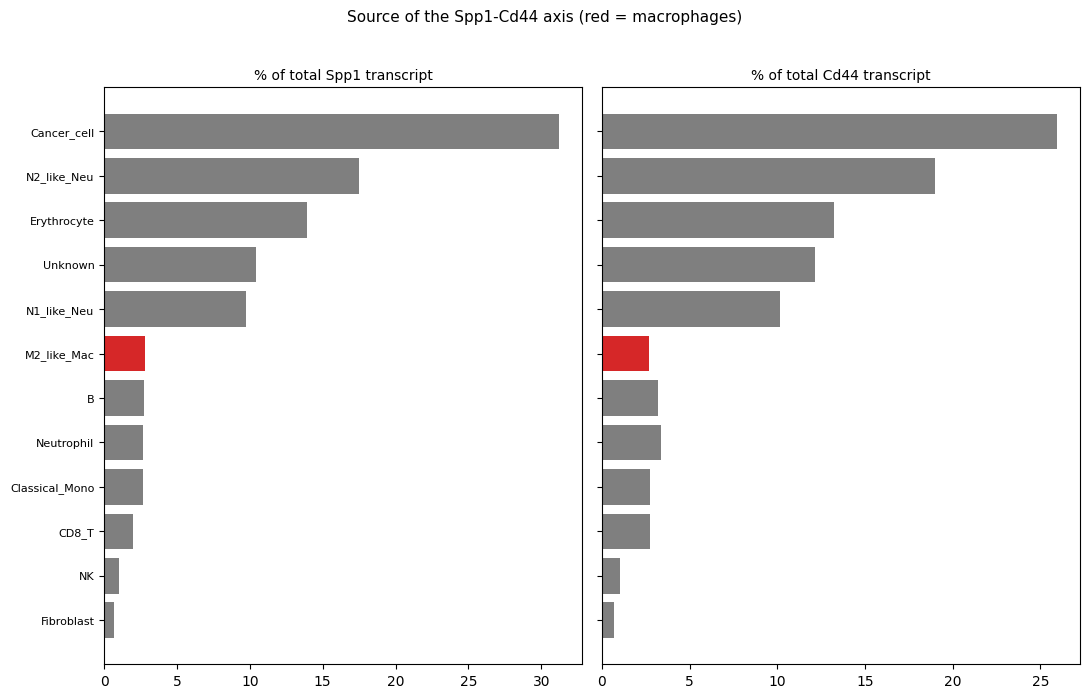

In [5]:
top = by_ct.nlargest(12, "pct_of_total_Spp1")
y = np.arange(len(top))
fig, axes = plt.subplots(1, 2, figsize=(11, 0.4 * len(top) + 2), sharey=True)
cols = ["#d62728" if i in MAC_LABELS else "#7f7f7f" for i in top.index]
axes[0].barh(y, top["pct_of_total_Spp1"], color=cols); axes[0].set_title("% of total Spp1 transcript", fontsize=10)
axes[1].barh(y, top["pct_of_total_Cd44"], color=cols); axes[1].set_title("% of total Cd44 transcript", fontsize=10)
axes[0].set_yticks(y); axes[0].set_yticklabels(top.index, fontsize=8); axes[0].invert_yaxis()
fig.suptitle("Source of the Spp1-Cd44 axis (red = macrophages)", y=1.02, fontsize=11)
fig.tight_layout(); fig.savefig(FIG_DIR / "spp1_cd44_sources.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 4. LIANA bivariate, per tissue

Per tissue, not pooled: a global run would build a spatial graph across tissues that are not
physically adjacent, and the local scores would be meaningless at the seams. Same parameters as
your original call (`cosine` local, `morans` global, `n_perms=100`, `nz_prop=0.05`,
`use_raw=False`), with `mouseconsensus`.

In [6]:
res = li.rs.select_resource("mouseconsensus")
res_genes = set(res["ligand"]).union(res["receptor"])
overlap = len(res_genes & set(adata.var_names.astype(str)))
print(f"mouseconsensus: {len(res)} LR pairs | {overlap}/{len(res_genes)} genes match var_names")
assert overlap > 100, ("mouseconsensus barely matches var_names - check species/case. "
                       "If this fires, the 'HUMAN gene symbols' comment in your old code was right.")
sp_cd44 = res[(res["ligand"] == "Spp1") & (res["receptor"] == "Cd44")]
print(f"Spp1->Cd44 present in resource: {len(sp_cd44) > 0}")
print(f"All Spp1-* pairs in resource: {sorted(res.loc[res['ligand']=='Spp1','receptor'].unique())}")

mouseconsensus: 3989 LR pairs | 1526/1741 genes match var_names
Spp1->Cd44 present in resource: True
All Spp1-* pairs in resource: ['Ccr8', 'Cd44', 'Itga4_Itgb1', 'Itga5_Itgb1', 'Itga8_Itgb1', 'Itga9_Itgb1', 'Itgav_Itgb1', 'Itgav_Itgb3', 'Itgav_Itgb5', 'Itgav_Itgb6', 'Ptger4', 'S1pr1']


In [ ]:
# The write-back at the bottom is label-based, so cell ids must be globally unique — otherwise
# one tissue's scores would be scattered into another tissue's rows with no error raised.
assert adata.obs_names.is_unique, "obs_names not unique -> LR_Spp1_Cd44 write-back would mis-assign"

def hires_scale(t):
    """Same pixel->micron scale factor 02/03/06 use, so all notebooks share one spatial scale."""
    k = f"{t}_cell_boundaries"
    if not APPLY_HIRES_SCALE or get_transformation is None or k not in sdata.shapes:
        return 1.0
    try:
        return float(get_transformation(sdata.shapes[k], get_all=True)["downscale_to_hires"].scale[0])
    except Exception:
        return 1.0

tissues = sorted(adata.obs[TISSUE_COL].astype(str).unique())
if TISSUE_SUBSET:
    tissues = [t for t in tissues if t in TISSUE_SUBSET]

INTERACTION = "Spp1^Cd44"      # liana names interactions <ligand>^<receptor>
local_scores, global_rows = {}, []

for ti, tname in enumerate(tissues, 1):
    sub = adata[adata.obs[TISSUE_COL].astype(str) == tname].copy()
    if sub.n_obs < MIN_CELLS:
        continue
    print(f"[{ti}/{len(tissues)}] {tname} n={sub.n_obs:,}", flush=True)
    # bandwidth is in the units of spatial_key -> give liana microns, not pixels
    sub.obsm["spatial_um"] = (np.asarray(sub.obsm["spatial"], float)
                              * hires_scale(tname) * MICRONS_PER_PIXEL)
    li.ut.spatial_neighbors(sub, bandwidth=LR_BANDWIDTH_UM, cutoff=LR_CUTOFF, kernel="misty_rbf",
                            set_diag=True, max_neighbours=LR_MAX_NEIGHBOURS,
                            spatial_key="spatial_um")
    lr = li.mt.bivariate(
        sub, resource_name="mouseconsensus", local_name="cosine", global_name="morans",
        n_perms=LR_N_PERMS, mask_negatives=False, add_categories=True,
        nz_prop=LR_NZ_PROP, use_raw=False, verbose=False, inplace=False,
    )
    if lr is None or INTERACTION not in set(lr.var_names):
        print(f"    {INTERACTION} not returned (likely nz_prop filter) - skipping")
        continue
    j = list(lr.var_names).index(INTERACTION)
    x = lr.X[:, j]
    vals = np.asarray(x.todense()).ravel() if sp.issparse(x) else np.asarray(x).ravel()
    local_scores[tname] = pd.Series(vals, index=lr.obs_names)

    if "cats" in lr.layers:
        c = lr.layers["cats"][:, j]
        cat = np.asarray(c.todense()).ravel() if sp.issparse(c) else np.asarray(c).ravel()
        local_scores[f"{tname}__cat"] = pd.Series(cat, index=lr.obs_names)

    grow = {"tissue": tname}
    for k in ("morans", "morans_pvals", "mean", "std"):
        if k in lr.var.columns:
            grow[k] = float(lr.var.iloc[j][k])
    global_rows.append(grow)
    del sub, lr

adata.obs["LR_Spp1_Cd44"] = np.nan
for t, s in local_scores.items():
    if t.endswith("__cat"):
        continue
    adata.obs.loc[s.index, "LR_Spp1_Cd44"] = s.values

global_lr = pd.DataFrame(global_rows)
global_lr.to_csv(OUT_DIR / "spp1_cd44_global_moran_per_tissue.csv", index=False)
print(f"\nlocal Spp1^Cd44 computed for {len([k for k in local_scores if not k.endswith('__cat')])} tissues")
print(global_lr.round(4).to_string(index=False))

[1/32] CyPSCA_1_1 n=108,895


ValueError: Unexpected keyword arguments: {'inplace'}

: 

## 5. Do high-signature (SPP1-TAM) macrophages sit in the Spp1-Cd44 field?

The direct form of your question, in two views:

- **Composition of the top decile** — of the cells with the highest local Spp1-Cd44, what are
  they, and are high-signature macs enriched vs their tissue-wide frequency?
- **Graded coupling within macs** — Spearman(`SPP1_TAM_sig`, local Spp1-Cd44) across macrophages
  in each tissue. Positive ρ = the more SPP1-TAM a mac is, the more Spp1-Cd44 field it sits in,
  with no threshold at all.

In [ ]:
rows, rho_rows = [], []
for t in [k for k in local_scores if not k.endswith("__cat")]:
    m = adata.obs[TISSUE_COL].astype(str).eq(t).values
    obs_t = adata.obs.loc[m]
    s = obs_t["LR_Spp1_Cd44"].astype(float)
    if s.notna().sum() < MIN_CELLS:
        continue
    thr = s.quantile(TOP_Q)
    hi = (s >= thr).values
    cond, loc, rep = parse_tissue(t)
    ct_t = obs_t[CELL_TYPE_COL].astype(str)

    comp = ct_t[hi].value_counts(normalize=True).mul(100)
    base = ct_t.value_counts(normalize=True).mul(100)
    for c in base.index:
        rows.append({"tissue": t, "cond": cond, "tumor_loc": loc, "rt_group": rt_group_of(cond, loc),
                     "celltype": c, "pct_in_topLR": float(comp.get(c, 0.0)),
                     "pct_in_tissue": float(base.get(c, 0.0)),
                     "log2_enrich": float(np.log2(comp.get(c, 0.0) / base[c]))
                                    if comp.get(c, 0.0) > 0 and base[c] > 0 else np.nan})
    # high-signature macs specifically
    high_u = obs_t["highsig_mac"].values.astype(bool)
    rows.append({"tissue": t, "cond": cond, "tumor_loc": loc, "rt_group": rt_group_of(cond, loc),
                 "celltype": "__HighSig_Mac", "pct_in_topLR": 100 * high_u[hi].mean(),
                 "pct_in_tissue": 100 * high_u.mean(),
                 "log2_enrich": float(np.log2(high_u[hi].mean() / high_u.mean()))
                                if high_u[hi].mean() > 0 and high_u.mean() > 0 else np.nan})
    # graded: signature vs local score, within macs
    mac_u = obs_t["is_mac"].values.astype(bool)
    sig_m = obs_t.loc[mac_u, "SPP1_TAM_sig"].astype(float).values
    lr_m  = s[mac_u].values
    good = np.isfinite(sig_m) & np.isfinite(lr_m)
    if good.sum() >= MIN_CELLS and np.nanstd(lr_m[good]) > 0:
        rho, pval = spearmanr(sig_m[good], lr_m[good])
        rho_rows.append({"tissue": t, "cond": cond, "tumor_loc": loc, "rt_group": rt_group_of(cond, loc),
                         "n_mac": int(good.sum()), "rho_sig_vs_LR": rho, "p": pval})

topLR = pd.DataFrame(rows)
topLR["log2_enrich"] = topLR["log2_enrich"].replace([np.inf, -np.inf], np.nan)
topLR.to_csv(OUT_DIR / "spp1_cd44_topdecile_composition_long.csv", index=False)

topLR_summary = (topLR.groupby("celltype", observed=True)
                 .agg(n_tissues=("tissue", "count"),
                      pct_in_topLR=("pct_in_topLR", "mean"),
                      pct_in_tissue=("pct_in_tissue", "mean"),
                      log2_enrich=("log2_enrich", "mean"),
                      frac_tissues_up=("log2_enrich", lambda s: (s > 0).mean()))
                 .sort_values("log2_enrich", ascending=False))
topLR_summary.to_csv(OUT_DIR / "spp1_cd44_topdecile_composition_summary.csv")

rho_sig = pd.DataFrame(rho_rows, columns=["tissue", "cond", "tumor_loc", "rt_group",
                                          "n_mac", "rho_sig_vs_LR", "p"])
rho_sig.to_csv(OUT_DIR / "spp1_cd44_sig_correlation_per_tissue.csv", index=False)

print(f"=== Who is in the top {int((1-TOP_Q)*100)}% of local Spp1-Cd44? ===")
print(topLR_summary.round(3).to_string())
print("\n'__HighSig_Mac' answers your question directly:")
if "__HighSig_Mac" in topLR_summary.index:
    r = topLR_summary.loc["__HighSig_Mac"]
    print(f"  high-signature macs are {r['pct_in_topLR']:.2f}% of high-Spp1-Cd44 cells "
          f"vs {r['pct_in_tissue']:.2f}% of the tissue -> log2 enrich {r['log2_enrich']:+.2f} "
          f"(consistent in {100*r['frac_tissues_up']:.0f}% of tissues)")
print("\n--- graded coupling: Spearman(SPP1_TAM_sig, local Spp1-Cd44) within macs, per tissue ---")
if len(rho_sig):
    print(rho_sig.round(4).to_string(index=False))
    print(f"\n  mean rho = {rho_sig['rho_sig_vs_LR'].mean():+.3f} | "
          f"positive in {100*(rho_sig['rho_sig_vs_LR']>0).mean():.0f}% of tissues")
    print("  positive & consistent -> SPP1-TAM macs localize into the Spp1-Cd44 field (a")
    print("      localization claim, agnostic to who produces the ligand - section 3 settles that).")
    print("  ~0 -> the SPP1-TAM program and the Spp1-Cd44 field are spatially independent.")

## 6. How does Spp1-Cd44 vary per condition?

In [ ]:
rows = []
for t in [k for k in local_scores if not k.endswith("__cat")]:
    m = adata.obs[TISSUE_COL].astype(str).eq(t).values
    obs_t = adata.obs.loc[m]
    s = obs_t["LR_Spp1_Cd44"].astype(float)
    if s.notna().sum() < MIN_CELLS:
        continue
    cond, loc, rep = parse_tissue(t)
    high_u = obs_t["highsig_mac"].values.astype(bool)
    g = global_lr.loc[global_lr["tissue"] == t]
    rows.append({
        "tissue": t, "cond": cond, "tumor_loc": loc, "rt_group": rt_group_of(cond, loc),
        "group": f"{cond}_{loc}",
        "mean_LR": float(s.mean()), "median_LR": float(s.median()),
        "pct_cells_top_decile": 100 * float((s >= s.quantile(TOP_Q)).mean()),
        "mean_LR_in_highsig_macs": float(s[high_u].mean()) if high_u.sum() else np.nan,
        "mean_LR_in_other": float(s[~high_u].mean()),
        "morans": float(g["morans"].iloc[0]) if len(g) and "morans" in g else np.nan,
    })
lr_cond = pd.DataFrame(rows)
lr_cond.to_csv(OUT_DIR / "spp1_cd44_by_tissue.csv", index=False)

print("--- Spp1-Cd44 per tissue ---")
print(lr_cond.round(4).to_string(index=False))
print("\n--- by condition x tumor location ---")
by_group = (lr_cond.groupby(["cond", "tumor_loc"], observed=True)
            .agg(n=("tissue", "count"), mean_LR=("mean_LR", "mean"),
                 mean_LR_in_highsig_macs=("mean_LR_in_highsig_macs", "mean"),
                 morans=("morans", "mean")).round(4))
print(by_group.to_string())
by_group.to_csv(OUT_DIR / "spp1_cd44_by_condition.csv")

In [ ]:
groups = sorted(lr_cond["group"].unique())
xmap = {g: i for i, g in enumerate(groups)}
colors = {"no_RT": "#4d4d4d", "RT_direct": "#d62728", "RT_abscopal": "#1f77b4"}
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, metric in zip(axes, ["mean_LR", "mean_LR_in_highsig_macs"]):
    for g in groups:
        sub = lr_cond[lr_cond["group"] == g]
        v = sub[metric].dropna().values
        ax.scatter(xmap[g] + rng.uniform(-0.12, 0.12, len(v)), v, s=45,
                   color=colors.get(sub["rt_group"].iloc[0] if len(sub) else "no_RT", "k"),
                   alpha=0.85, linewidths=0)
        if len(v):
            ax.hlines(np.median(v), xmap[g] - 0.25, xmap[g] + 0.25, color="k", lw=1.5)
    ax.set_xticks(list(xmap.values())); ax.set_xticklabels(groups, rotation=45, ha="right", fontsize=8)
    ax.set_title(metric, fontsize=10)
fig.suptitle("Local Spp1-Cd44 score by condition (dot = tissue)", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "spp1_cd44_by_condition.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

def contrast(df, col, af, bf, an, bn):
    a, b = df[af(df)][col].dropna().values, df[bf(df)][col].dropna().values
    if len(a) < 2 or len(b) < 2:
        return None
    u = mannwhitneyu(a, b, alternative="two-sided")
    return {"contrast": f"{an} vs {bn}", "metric": col, "n_a": len(a), "n_b": len(b),
            "mean_a": a.mean(), "mean_b": b.mean(), "diff": a.mean() - b.mean(),
            "cliffs_delta": 2 * u.statistic / (len(a) * len(b)) - 1, "mwu_p": u.pvalue}

CONTRASTS = [
    (lambda d: d["cond"].str.startswith("RT"), lambda d: ~d["cond"].str.startswith("RT"), "RT_any", "no_RT"),
    (lambda d: d["rt_group"] == "RT_direct",   lambda d: d["rt_group"] == "RT_abscopal", "RT_direct", "RT_abscopal"),
    (lambda d: d["group"] == "RTCyPSCA_1",     lambda d: d["group"] == "CyPSCA_1", "RTCyPSCA_1", "CyPSCA_1"),
    (lambda d: d["group"] == "RTCyPSCA_2",     lambda d: d["group"] == "CyPSCA_2", "RTCyPSCA_2", "CyPSCA_2"),
]
rows = [r for m in ["mean_LR", "mean_LR_in_highsig_macs", "morans"]
        for af, bf, an, bn in CONTRASTS if (r := contrast(lr_cond, m, af, bf, an, bn))]
lr_contrasts = pd.DataFrame(rows)
lr_contrasts.to_csv(OUT_DIR / "spp1_cd44_contrasts.csv", index=False)
print("--- Spp1-Cd44 RT contrasts (replicate-level; small n, read effect sizes) ---")
print(lr_contrasts.round(4).to_string(index=False))

print(f"""
YOUR DECK CLAIMS multidose RT REDUCES Spp1-CD44-high clustering.
That predicts a NEGATIVE diff for 'RT_direct vs no_RT' / 'RTCyPSCA_1 vs CyPSCA_1' above.
If the sign is positive, the spatial data disagrees with the deck and that needs reconciling
before it goes in a figure - the two analyses were computed differently (this one is
per-tissue, mouseconsensus, cosine local score) and the deck's version may not measure the
same quantity.
""")

## 7. Handoff + summary

In [ ]:
adata.obs[[TISSUE_COL, CELL_TYPE_COL, "Spp1_counts", "Cd44_counts", "SPP1_TAM_sig",
           "is_mac", "highsig_mac", "LR_Spp1_Cd44"]].to_parquet(OUT_DIR / "spp1_cd44_cell_scores.parquet")

print(f"""
==================== SUMMARY — report these back ====================
Tissues with Spp1^Cd44 : {lr_cond['tissue'].nunique()}
Macrophage share of Spp1: {mac_share:.1f}%   <- THE GATE (section 3)
Top Spp1 source         : {top_src} ({by_ct.loc[top_src,'pct_of_total_Spp1']:.1f}%)

High-signature macs in top-decile Spp1-Cd44:
{topLR_summary.loc[['__HighSig_Mac']].round(3).to_string() if '__HighSig_Mac' in topLR_summary.index else '  n/a'}
Graded coupling within macs (Spearman sig vs local Spp1-Cd44): mean rho = {rho_sig['rho_sig_vs_LR'].mean():+.3f} across {len(rho_sig)} tissues

THE THREE THINGS TO CHECK
 1. Sec 3 - macrophage share of Spp1. Low share + Cancer_cell dominant => tumor-driven axis;
    reframe to "SPP1-TAM macs LOCALIZE to a tumor-driven Spp1-CD44 niche" (still the PDF's model).
 2. Sec 5 - are high-signature macs enriched in high-Spp1-Cd44 cells, and is the graded rho
    positive & consistent? Together they say whether SPP1-TAM macs sit in the field. A null is a
    real, reportable result, not a failed analysis.
 3. Sec 6 - does the RT direction match the deck's "multidose RT reduces SPP1-CD44-high
    clustering"? Sign disagreement => reconcile before publishing either.

CAVEAT: LIANA's local score is a LOCAL CO-EXPRESSION statistic, not proof of physical
ligand-receptor binding. It cannot distinguish "mac signals to tumor" from "mac sits next to
tumor and both happen to be positive". Directionality needs the co-culture work in the PDF's
validation section - do not over-claim it from this analysis alone.
=====================================================================
""")